IMPORT LIBRARIES

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [69]:
df = pd.read_csv("../data/airline_route_profitability.csv")
df.head()

,Flight_Number,Flight_Date,Origin,Destination,Route,Aircraft_Type,Aircraft_Capacity,Passengers,Load_Factor,Flight_Hours,...,Handling_Cost,Navigation_Fees,Sales_Distribution_Cost,Passenger_Service_Cost,Overhead_Cost,Marketing_Cost,IT_Systems_Cost,Total_Cost,Profit,Profit_Margin
0,EK8960,2024-12-20,DXB,ORD,DXB-ORD,Boeing 777-300ER,396,308,0.7791,14.5,...,4460.11,10636.90,78193.60,5100.09,88545.73,25883.92,3769.37,506421.77,-42204.34,-9.09
1,EK3960,2024-05-13,DXB,HYD,DXB-HYD,Boeing 787-9,296,234,0.7910,4.2,...,5425.84,3027.25,21586.21,6022.20,17057.61,8820.56,1937.81,123323.88,40261.57,24.61
2,EK7529,2024-10-12,DXB,CDG,DXB-CDG,Boeing 787-9,296,251,0.8502,7.5,...,3761.85,3431.70,100188.97,6514.22,31347.38,23695.34,3415.99,282266.09,399299.10,58.59
3,EK4543,2024-06-25,DXB,DEL,DXB-DEL,Boeing 787-9,296,229,0.7748,3.5,...,4440.93,2079.79,22686.82,4791.21,15328.62,6795.49,2245.61,113919.11,30109.31,20.91
4,EK3114,2024-04-20,DXB,RUH,DXB-RUH,Airbus A320,180,142,0.7901,2.2,...,3414.18,1662.49,5133.62,3094.65,8252.23,1492.53,1273.27,46580.86,-10058.06,-27.54


In [70]:
df.shape

(7974, 33)

In [71]:
df.columns

Index(['Flight_Number', 'Flight_Date', 'Origin', 'Destination', 'Route',
       'Aircraft_Type', 'Aircraft_Capacity', 'Passengers', 'Load_Factor',
       'Flight_Hours', 'Season', 'Route_Category', 'Demand_Level',
       'Ticket_Revenue', 'Ancillary_Revenue', 'Total_Revenue', 'Fuel_Cost',
       'Maintenance_Cost', 'Crew_Cost', 'Depreciation_Cost', 'Insurance_Cost',
       'Airport_Fees', 'Catering_Cost', 'Handling_Cost', 'Navigation_Fees',
       'Sales_Distribution_Cost', 'Passenger_Service_Cost', 'Overhead_Cost',
       'Marketing_Cost', 'IT_Systems_Cost', 'Total_Cost', 'Profit',
       'Profit_Margin'],
      dtype='str')

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7974 entries, 0 to 7973
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Flight_Number            7974 non-null   str    
 1   Flight_Date              7974 non-null   str    
 2   Origin                   7974 non-null   str    
 3   Destination              7974 non-null   str    
 4   Route                    7974 non-null   str    
 5   Aircraft_Type            7974 non-null   str    
 6   Aircraft_Capacity        7974 non-null   int64  
 7   Passengers               7974 non-null   int64  
 8   Load_Factor              7974 non-null   float64
 9   Flight_Hours             7974 non-null   float64
 10  Season                   7974 non-null   str    
 11  Route_Category           7974 non-null   str    
 12  Demand_Level             7974 non-null   str    
 13  Ticket_Revenue           7974 non-null   float64
 14  Ancillary_Revenue        7703 non-n

In [73]:
df.describe()

,Aircraft_Capacity,Passengers,Load_Factor,Flight_Hours,Ticket_Revenue,Ancillary_Revenue,Total_Revenue,Fuel_Cost,Maintenance_Cost,Crew_Cost,...,Handling_Cost,Navigation_Fees,Sales_Distribution_Cost,Passenger_Service_Cost,Overhead_Cost,Marketing_Cost,IT_Systems_Cost,Total_Cost,Profit,Profit_Margin
count,7974.000000,7974.000000,7974.000000,7974.000000,7.974000e+03,7703.000000,7.974000e+03,7974.000000,7974.000000,7974.000000,...,7718.000000,7974.000000,7974.000000,7974.000000,7974.000000,7974.000000,7974.000000,7974.000000,7974.000000,7974.000000
mean,317.800602,254.819162,0.801570,6.327314,2.643839e+05,33073.717197,2.974362e+05,46296.405878,18973.224856,8905.116880,...,3988.998616,3785.569431,44659.242364,5721.982070,35742.265706,13448.184059,2930.738501,225266.563756,72169.633934,6.190222
std,98.768543,88.141968,0.087755,4.555668,2.371022e+05,30167.518230,2.668329e+05,43123.036900,17677.194300,7414.772748,...,1146.741218,2861.881472,40575.117395,2295.208112,29368.802114,12633.987523,1154.464363,174526.327680,138692.750890,39.040588
min,180.000000,104.000000,0.576600,1.200000,1.481234e+04,1616.620000,1.665002e+04,2592.620000,1380.000000,936.000000,...,2000.040000,483.570000,2143.110000,1750.110000,3750.190000,608.620000,923.260000,28019.380000,-250914.850000,-236.270000
25%,296.000000,180.250000,0.736825,3.200000,5.642951e+04,7234.405000,6.350239e+04,16137.575000,7040.000000,3840.000000,...,2991.377500,1602.465000,9690.980000,4002.195000,13955.147500,2942.397500,2063.495000,83612.367500,-9052.485000,-10.747500
50%,325.000000,246.000000,0.801500,4.500000,1.826204e+05,22842.850000,2.048126e+05,28344.950000,11200.000000,5850.000000,...,3971.835000,2879.290000,31167.845000,5386.070000,24366.945000,9235.870000,2772.270000,154808.355000,21326.055000,15.215000
75%,396.000000,302.000000,0.873100,7.500000,4.126969e+05,51234.975000,4.638002e+05,74832.960000,30800.000000,13000.000000,...,4974.315000,5084.895000,68973.712500,7018.972500,54205.342500,20226.527500,3576.795000,355441.002500,116046.090000,33.280000
max,517.000000,491.000000,0.950000,16.500000,1.303645e+06,192921.910000,1.496567e+06,191047.780000,72500.000000,29000.000000,...,5999.980000,13166.360000,222595.180000,14601.280000,144736.040000,78018.070000,7354.160000,835108.700000,972133.760000,64.960000


In [74]:
df.isnull().sum()

Flight_Number                0
Flight_Date                  0
Origin                       0
Destination                  0
Route                        0
Aircraft_Type                0
Aircraft_Capacity            0
Passengers                   0
Load_Factor                  0
Flight_Hours                 0
Season                       0
Route_Category               0
Demand_Level                 0
Ticket_Revenue               0
Ancillary_Revenue          271
Total_Revenue                0
Fuel_Cost                    0
Maintenance_Cost             0
Crew_Cost                    0
Depreciation_Cost            0
Insurance_Cost               0
Airport_Fees                 0
Catering_Cost              265
Handling_Cost              256
Navigation_Fees              0
Sales_Distribution_Cost      0
Passenger_Service_Cost       0
Overhead_Cost                0
Marketing_Cost               0
IT_Systems_Cost              0
Total_Cost                   0
Profit                       0
Profit_M

Handle Missing Values

In [75]:
df['Ancillary_Revenue'].fillna(df['Ancillary_Revenue'].median(), inplace=True)

df['Catering_Cost'].fillna(df['Catering_Cost'].median(), inplace=True)

df['Handling_Cost'].fillna(df['Handling_Cost'].median(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_23172\163177977.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Ancillary_Revenue'].fillna(df['Ancillary_Revenue'].median(), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_23172\163177977.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Serie

0       4460.11
1       5425.84
2       3761.85
3       4440.93
4       3414.18
         ...   
7969    5581.69
7970    2336.67
7971    5982.81
7972    5890.34
7973    3573.41
Name: Handling_Cost, Length: 7974, dtype: float64

covert data to columns

In [76]:
df['Flight_Date'] = pd.to_datetime(df['Flight_Date'])
df['Month'] = df['Flight_Date'].dt.month
df['Day'] = df['Flight_Date'].dt.day
df['Weekday'] = df['Flight_Date'].dt.weekday

EDA

Profit Distribution

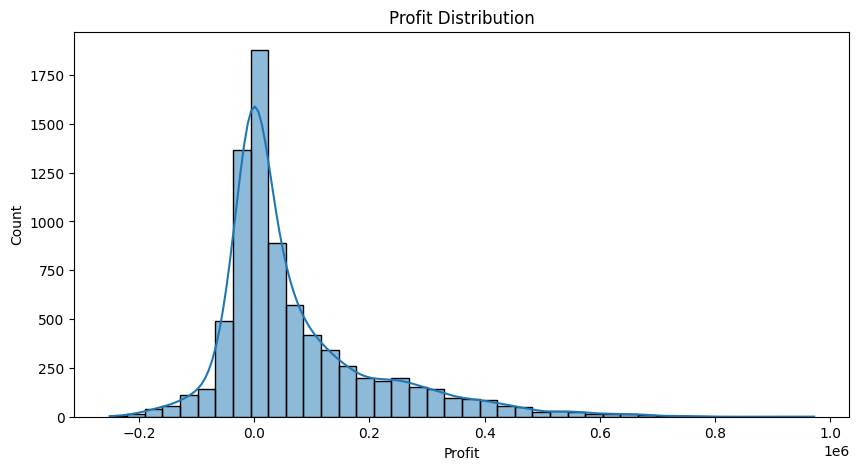

In [77]:
plt.figure(figsize=(10,5))
sns.histplot(df['Profit'], bins=40, kde=True)
plt.title("Profit Distribution")
plt.show()

Aircraft vs Profit

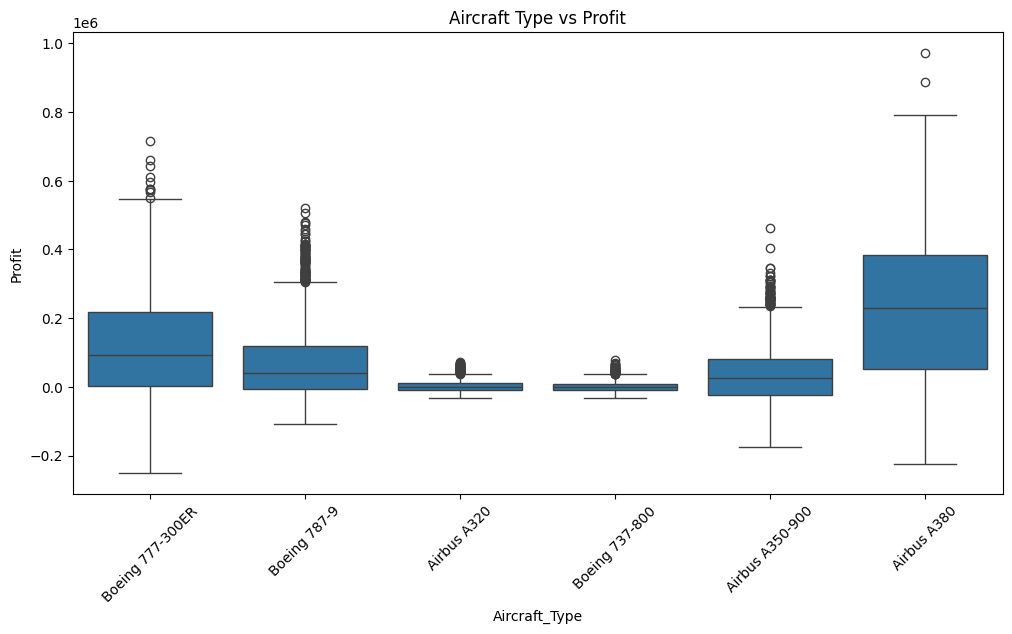

In [78]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Aircraft_Type', y='Profit', data=df)
plt.xticks(rotation=45)
plt.title("Aircraft Type vs Profit")
plt.show()

Route Category vs Profit

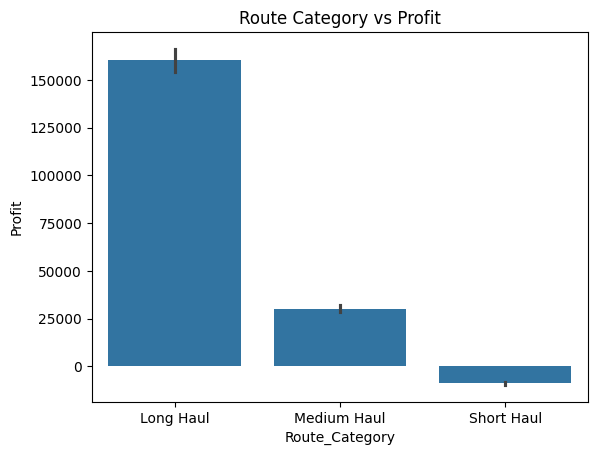

In [79]:
sns.barplot(x='Route_Category', y='Profit', data=df)
plt.title("Route Category vs Profit")
plt.show()

Passenger Load vs Profit

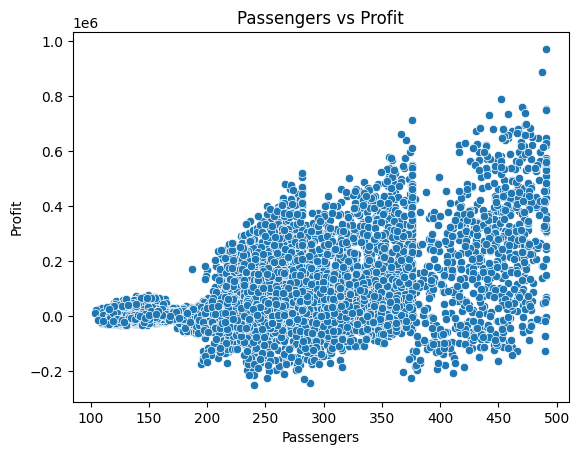

In [80]:
sns.scatterplot(x='Passengers', y='Profit', data=df)
plt.title("Passengers vs Profit")
plt.show()

Correlation Heatmap

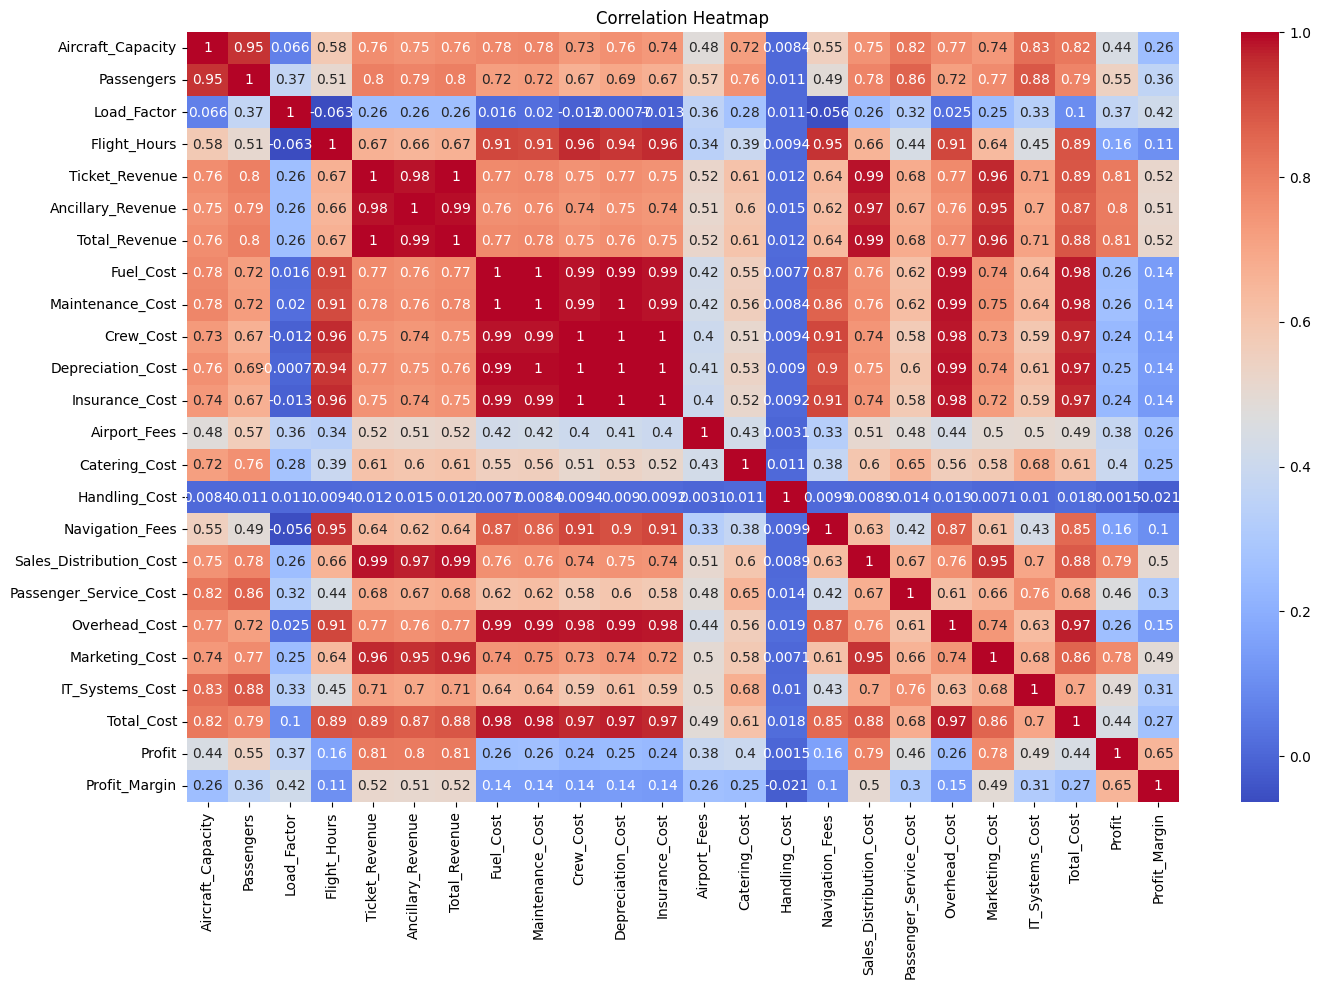

In [81]:
plt.figure(figsize=(16,10))

sns.heatmap(
    df.select_dtypes(include=['float64','int64']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Feature Engineering

Revenue Per Passenger

In [82]:
df['Revenue_Per_Passenger'] = df['Total_Revenue'] / df['Passengers']

Cost Per Passenger

In [83]:
df['Cost_Per_Passenger'] = df['Total_Cost'] / df['Passengers']

Profit Per Flight Hour

In [84]:
df['Profit_Per_Hour'] = df['Profit'] / df['Flight_Hours']

In [85]:
df['Ancillary_Revenue'] = df['Ancillary_Revenue'].fillna(
    df['Ancillary_Revenue'].median()
)

df['Catering_Cost'] = df['Catering_Cost'].fillna(
    df['Catering_Cost'].median()
)

df['Handling_Cost'] = df['Handling_Cost'].fillna(
    df['Handling_Cost'].median()
)

remove unnecessary columns

In [86]:
X = df.drop(columns=[
    'Profit',
    'Profit_Margin',
    'Total_Revenue',
    'Total_Cost',
    'Flight_Number',
    'Flight_Date',
    'Origin',
    'Destination',
    'Route'
])

y = df['Profit']

In [87]:
X = pd.get_dummies(X, drop_first=True)
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median())

Encode Categorical Columns

In [88]:
X = pd.get_dummies(X, drop_first=True)
print(X.shape)
print(y.shape)

(7974, 37)
(7974,)


train/test split

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Linear Regression

In [90]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [91]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred_lr)

mse = mean_squared_error(y_test, y_pred_lr)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred_lr)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 2249.1088393948526
RMSE: 3969.3505121558374
R2 Score: 0.9991768391517546


Train Random Forest

In [93]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

evluations

In [94]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = mse_rf ** 0.5

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE : 2248.198518683385
RMSE: 4565.851020479457
R2 Score: 0.9989108460323843


feature importance

In [95]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(10))

                  Feature  Importance
25        Profit_Per_Hour    0.773476
4          Ticket_Revenue    0.143273
23  Revenue_Per_Passenger    0.061627
17          Overhead_Cost    0.006769
6               Fuel_Cost    0.006336
3            Flight_Hours    0.002419
24     Cost_Per_Passenger    0.001866
5       Ancillary_Revenue    0.000898
8               Crew_Cost    0.000615
14        Navigation_Fees    0.000451


visualize top features

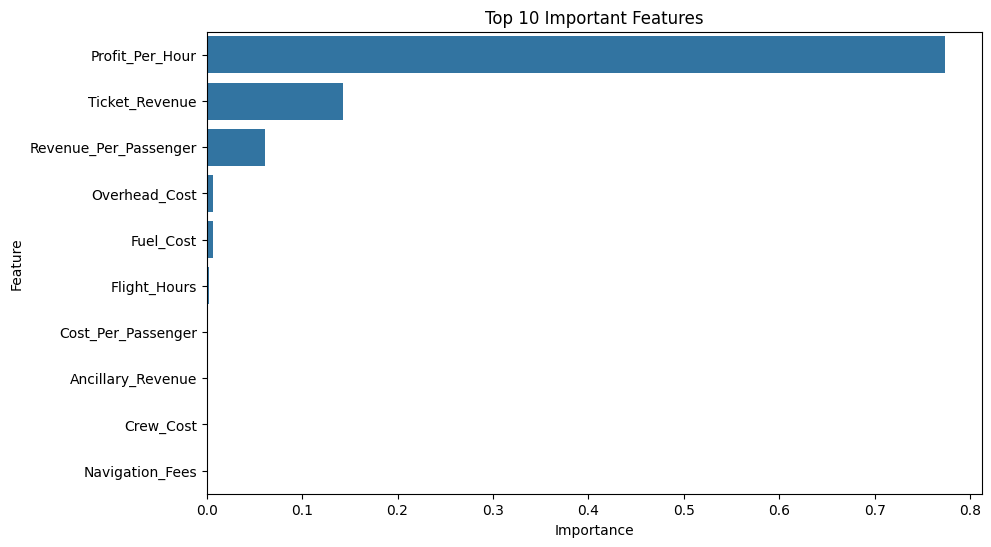

In [96]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")
plt.show()

Available Aircraft Types

In [97]:
df['Aircraft_Type'].unique()

<ArrowStringArray>
['Boeing 777-300ER',     'Boeing 787-9',      'Airbus A320',
   'Boeing 737-800',  'Airbus A350-900',      'Airbus A380']
Length: 6, dtype: str

sample input

In [98]:
sample_input = {
    'Aircraft_Capacity': 180,
    'Passengers': 160,
    'Load_Factor': 0.89,
    'Flight_Hours': 3.5,
    'Season': 'Peak',
    'Route_Category': 'Medium Haul',
    'Demand_Level': 'High',
    'Fuel_Cost': 25000,
    'Maintenance_Cost': 12000,
    'Crew_Cost': 8000,
    'Depreciation_Cost': 6000,
    'Insurance_Cost': 3000,
    'Airport_Fees': 5000,
    'Catering_Cost': 2000,
    'Handling_Cost': 1500,
    'Navigation_Fees': 2500,
    'Sales_Distribution_Cost': 1200,
    'Passenger_Service_Cost': 2200,
    'Overhead_Cost': 1800,
    'Marketing_Cost': 1000,
    'IT_Systems_Cost': 900,
    'Ticket_Revenue': 85000,
    'Ancillary_Revenue': 10000,
    'Month': 6,
    'Day': 15,
    'Weekday': 2
}

main logic

create aircraft optimization

In [104]:
def recommend_best_aircraft(sample_input, aircraft_list, model, X_columns):

    aircraft_configs = {
        'Airbus A320': {
            'Aircraft_Capacity': 180,
            'Fuel_Cost': 25000,
            'Maintenance_Cost': 12000
        },

        'Boeing 737-800': {
            'Aircraft_Capacity': 190,
            'Fuel_Cost': 27000,
            'Maintenance_Cost': 13000
        },

        'Boeing 787-9': {
            'Aircraft_Capacity': 290,
            'Fuel_Cost': 50000,
            'Maintenance_Cost': 25000
        },

        'Boeing 777-300ER': {
            'Aircraft_Capacity': 396,
            'Fuel_Cost': 65000,
            'Maintenance_Cost': 32000
        },

        'Airbus A350-900': {
            'Aircraft_Capacity': 325,
            'Fuel_Cost': 58000,
            'Maintenance_Cost': 28000
        },

        'Airbus A380': {
            'Aircraft_Capacity': 500,
            'Fuel_Cost': 85000,
            'Maintenance_Cost': 40000
        }
    }

    results = []

    for aircraft in aircraft_list:

        temp_input = sample_input.copy()

        temp_input['Aircraft_Type'] = aircraft

        temp_input['Aircraft_Capacity'] = aircraft_configs[aircraft]['Aircraft_Capacity']

        temp_input['Fuel_Cost'] = aircraft_configs[aircraft]['Fuel_Cost']

        temp_input['Maintenance_Cost'] = aircraft_configs[aircraft]['Maintenance_Cost']

        temp_df = pd.DataFrame([temp_input])

        temp_df = pd.get_dummies(temp_df)

        temp_df = temp_df.reindex(columns=X_columns, fill_value=0)

        predicted_profit = model.predict(temp_df)[0]

        results.append({
            'Aircraft_Type': aircraft,
            'Predicted_Profit': predicted_profit
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by='Predicted_Profit',
        ascending=False
    )

    return results_df

      Aircraft_Type  Predicted_Profit
0  Boeing 777-300ER           52.6707
4   Airbus A350-900           42.2354
1      Boeing 787-9           37.3902
2       Airbus A320           35.7323
3    Boeing 737-800           35.3834
5       Airbus A380            5.2081


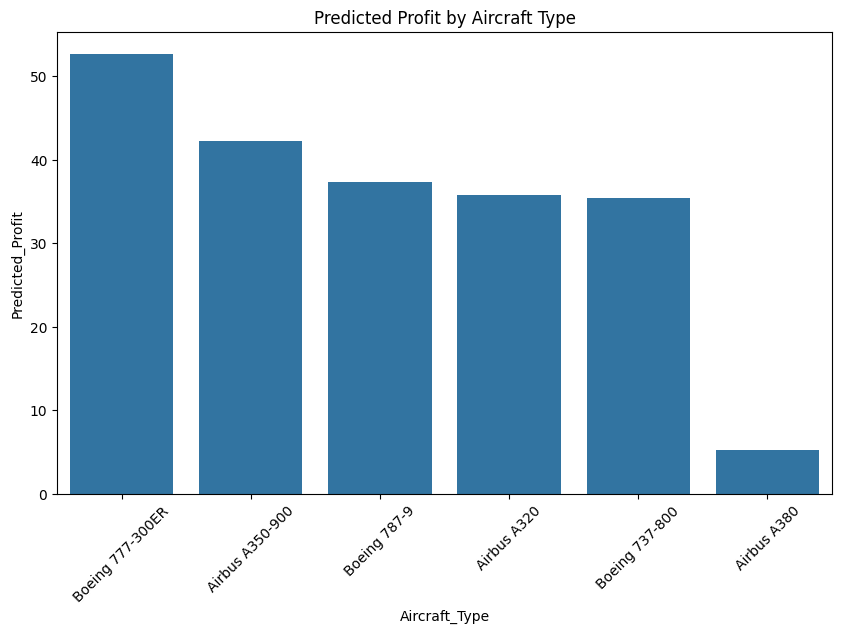

In [107]:
aircraft_list = df['Aircraft_Type'].unique()

recommendations = recommend_best_aircraft(
    sample_input,
    aircraft_list,
    rf_model,
    X.columns
)

print(recommendations)
plt.figure(figsize=(10,6))

sns.barplot(
    x='Aircraft_Type',
    y='Predicted_Profit',
    data=recommendations
)

plt.title("Predicted Profit by Aircraft Type")

plt.xticks(rotation=45)

plt.show()

In [116]:
import os
import joblib

# Create folder INSIDE notebooks
os.makedirs("models", exist_ok=True)

# Save model
joblib.dump(rf_model, "models/rf_model.pkl")

# Save columns
joblib.dump(X.columns.tolist(), "models/model_columns.pkl")

print("Saved successfully!")

Saved successfully!


In [117]:
import os

print(os.getcwd())

c:\Users\Admin\Desktop\Optimal-Aircraft-Assignment\notebooks
